# Optimal Analysis

This section synthesizes insights to determine the most optimal roles, skills, and locations for data professionals. By considering demand, salary, and skill requirements, it provides actionable recommendations for career optimization, guiding professionals on the best markets and competencies to focus on.

## Most Optimal Job Roles in the Data Industry

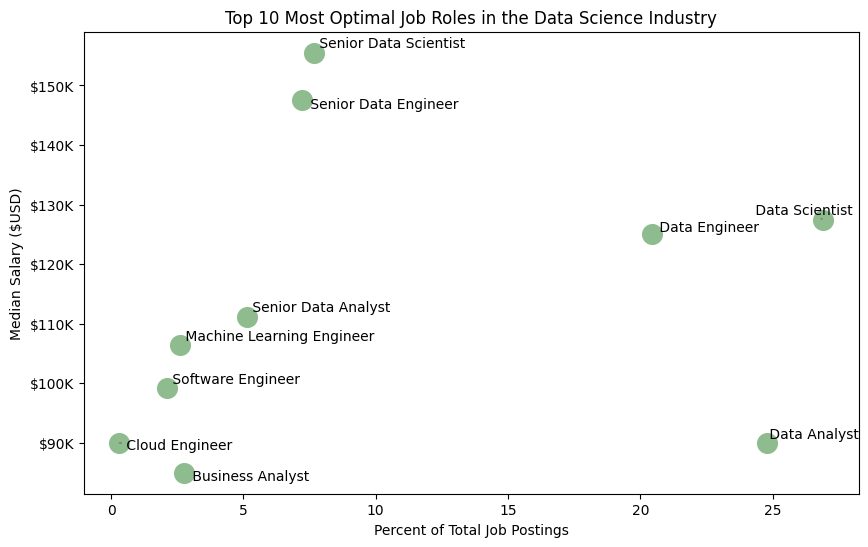

In [ ]:
# Prepare Data: Drops NA
df_dropped = df.dropna(subset=['salary_year_avg'])

# Build Data: Groups data and calculates job count, median salary, and job posting percentage. Then selects top 10.
df_titles = df_dropped.groupby('job_title_short')['salary_year_avg'].agg(['count', 'median']).rename(columns={'count': 'job_count', 'median': 'median_salary'})
total_jobs = len(df_dropped)
df_titles['job_percent'] = (df_titles['job_count'] / total_jobs) * 100
df_top_titles = df_titles.sort_values(by='job_count', ascending=False).head(10)

# Plot and Visualize
plt.figure(figsize=(10, 6))
plt.scatter(df_top_titles['job_percent'], df_top_titles['median_salary'], color='darkseagreen', s=200)

plt.title('Top 10 Most Optimal Job Roles in the Data Science Industry')
plt.xlabel('Percent of Total Job Postings')
plt.ylabel('Median Salary ($USD)')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

# Plot: Adds text labels
texts = [plt.text(row['job_percent'], row['median_salary'], " " + title) for title, row in df_top_titles.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

This visualization highlights the trade-off between salary and job availability for various data roles. Data Scientists and Data Engineers dominate in demand while maintaining strong median salaries above $120K. Senior-level roles, such as Senior Data Scientist and Senior Data Engineer, offer the highest salaries (above $150K) but with much lower job availability, emphasizing the exclusivity of these positions.

Machine Learning Engineers and Software Engineers have greater median salary than Data Analysts but with less job postings, perhaps due to the specialized nature of these roles. While Cloud Engineers and Business Analysts have relatively lower salaries and limited demand, suggesting they may not be as lucrative within the data field.

## Most Optimal Skills in the Data Industry

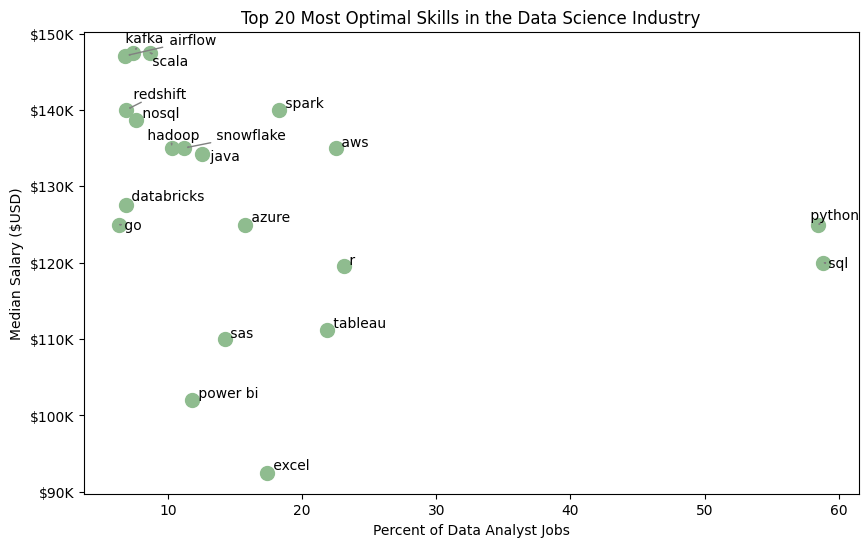

In [ ]:
# Prepare Data: Drops NA and unpacks job_skills
df_dropped = df.dropna(subset=['salary_year_avg'])
df_exploded = df_dropped.explode('job_skills')

# Build Data: Groups data and calculates job count, median salary, and job posting percentage. Then selects top 20.
df_skills = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).rename(columns={'count': 'skill_count', 'median': 'median_salary'})
job_count = len(df_dropped)
df_skills['skill_percent'] = df_skills['skill_count'] / job_count * 100
df_skills_high_demand = df_skills[df_skills['skill_percent'] > 0].sort_values(by='skill_percent', ascending=False).head(20)

# Plot and Visualize
plt.figure(figsize=(10, 6))
plt.scatter(df_skills_high_demand['skill_percent'], df_skills_high_demand['median_salary'], color='darkseagreen', s=100)

plt.title('Top 20 Most Optimal Skills in the Data Science Industry')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

# Plot: Adds text labels
texts = [plt.text(row['skill_percent'], row['median_salary'], " " + skill) for skill, row in df_skills_high_demand.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

The skill distribution shows that Python and SQL are the most in-demand skills, appearing in nearly 60% of job postings, but their median salaries are lower compared to more niche skills. High-paying specialized skills such as Kafka, Airflow, Scala, Redshift, and NoSQL are primarily focused on data engineering and infrastructure, indicating that cloud computing, big data, and automation expertise yield higher salaries. While skills like Tableau, Power BI, and Excel are commonly required, they do not command high salaries, reinforcing that technical depth in backend and cloud technologies drives higher compensation.

## Best Countries to Work in the Data Industry

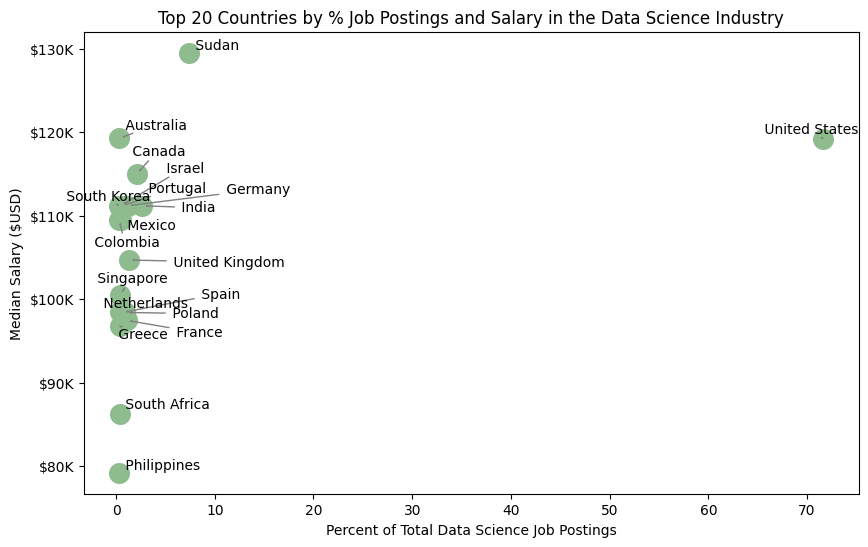

In [ ]:
# Prepare Data: Drops NA
df_dropped = df.dropna(subset=['salary_year_avg'])

# Build Data: Groups data and calculates job count, median salary, and job posting percentage. Then selects top 20.
df_countries = df_dropped.groupby('job_country')['salary_year_avg'].agg(['count', 'median']).rename(columns={'count': 'job_count', 'median': 'median_salary'})
total_jobs = len(df_dropped)
df_countries['job_percent'] = (df_countries['job_count'] / total_jobs) * 100
df_top_countries = df_countries.sort_values(by='job_count', ascending=False).head(20)

# Plot and Visualize
plt.figure(figsize=(10, 6))
plt.scatter(df_top_countries['job_percent'], df_top_countries['median_salary'], color='darkseagreen', s=200)

plt.title('Top 20 Countries by % Job Postings and Salary in the Data Science Industry')
plt.xlabel('Percent of Total Data Science Job Postings')
plt.ylabel('Median Salary ($USD)')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

# Plot: Adds text labels
texts = [plt.text(row['job_percent'], row['median_salary'], " " + country) for country, row in df_top_countries.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

The United States dominates in both job postings and salary, standing significantly apart from other countries. Sudan surprisingly offers one of the highest median salaries (~$130K). Countries like Australia, Canada, and Germany offer strong salaries and moderate job availability, making them attractive locations for data professionals. Meanwhile, emerging markets such as India, Mexico, and Singapore show increasing job opportunities but at slightly lower median salaries. Countries like the Philippines and South Africa have lower salaries and fewer postings, which may indicate limited demand or a developing market for data science professionals.